In [82]:
import pandas as pd
import mysql.connector as mc
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
mydb=mc.connect(host="localhost",user="root",passwd="avinash@1234",database = "Sales_data_db")

In [71]:
if mydb.is_connected():
    res = pd.read_sql("""Select Product_Name, sum(Unit_sold) as total_qty,
                        SUM(Unit_sold * unit_price) AS revenue 
                        From Sales 
                        group by Product_Name""",mydb)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14832\787242676.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  res = pd.read_sql("""Select Product_Name, sum(Unit_sold) as total_qty,


In [72]:
res

,Product_Name,total_qty,revenue
0,iPhone 14 Pro,2.0,1999.979980
1,Dyson V11 Vacuum,1.0,499.989990
2,Levi's 501 Jeans,3.0,209.969994
3,The Da Vinci Code,4.0,63.959999
4,Neutrogena Skincare Set,1.0,89.989998
...,...,...,...
227,Nespresso Vertuo Next Coffee and Espresso Maker,1.0,159.990005
228,Nike Air Force 1 Sneakers,3.0,270.000000
229,The Handmaid's Tale by Margaret Atwood,3.0,32.969999
230,Sunday Riley Luna Sleeping Night Oil,1.0,55.000000


In [ ]:
if mydb.is_connected():
    res2 = pd.read_sql("""SELECT 
    YEAR(Date_) AS order_year,
    MONTH(Date_) AS order_month,
    COUNT(DISTINCT Transaction_id) AS order_volume
FROM 
    Sales
GROUP BY 
    YEAR(Date_),
    MONTH(Date_)
ORDER BY 
    order_year, order_month;""",mydb)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14832\1539939228.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""SELECT


In [77]:
res2

,order_year,order_month,order_volume
0,2024,1,31
1,2024,2,29
2,2024,3,31
3,2024,4,30
4,2024,5,31
5,2024,6,30
6,2024,7,31
7,2024,8,27


In [78]:
if mydb.is_connected():
    df = pd.read_sql("""SELECT 
    Product_Category,
    COUNT(DISTINCT Transaction_ID) AS order_volume,  -- Number of unique orders per category
    SUM(Revenue) AS total_revenue  -- Total revenue per category
FROM 
    Sales
GROUP BY 
    Product_Category
ORDER BY 
    total_revenue DESC;""",mydb)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14832\269174781.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""SELECT


In [79]:
df

,Product_Category,order_volume,total_revenue
0,Electronics,40,34982.409691
1,Home Appliances,40,18646.159904
2,Sports,40,14326.519886
3,Clothing,40,8128.930054
4,Beauty Products,40,2621.899998
5,Books,40,1861.930000


Text(0, 0.5, 'Total Revenue')

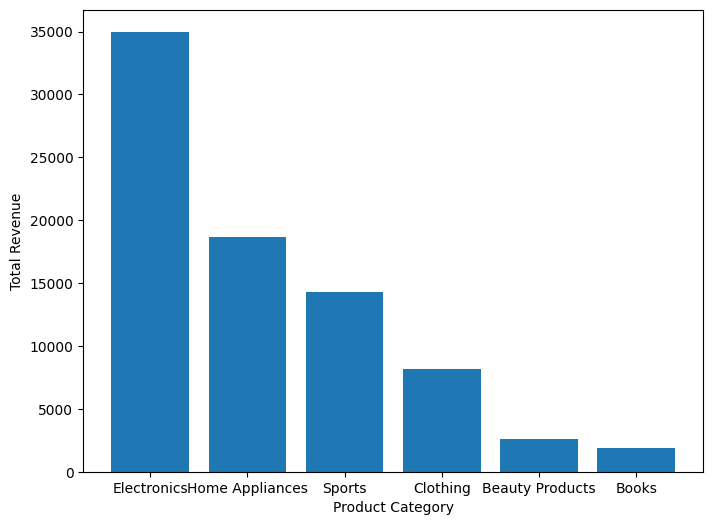

In [92]:
plt.figure(figsize=(8,6))
plt.bar(df["Product_Category"],df['total_revenue'])
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

In [93]:
mydb.close()